# Gemini Raw Lyrics Overview

This notebook inspects the `gemini_raw_lyrics` table, joins it back to Rekordbox metadata, and summarizes coverage plus basic JSON/lyrics-shape quality checks.

## tl;dr

In [1]:
from pathlib import Path
import json
import os
import sqlite3
from collections import Counter

import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if load_dotenv:
    load_dotenv(PROJECT_ROOT / ".env")

db_path = Path(os.getenv("SQLITE_DB_PATH", "data/rekordbox_tracks.sqlite3"))
if not db_path.is_absolute():
    db_path = PROJECT_ROOT / db_path

if not db_path.exists():
    raise FileNotFoundError(f"SQLite database not found: {db_path}")

LYRICS_GENRES = [
    "Dancehall",
    "Drill Rap",
    "Funk",
    "Hip-Hop",
    "Atmospheric Trap",
    "Alternative R&B",
    "Pop",
    "R&B",
    "Rage Rap",
    "Rap",
    "Rap & Hip-Hop",
    "Reggae",
    "Reggaeton",
    "Soft Rock",
]
lyrics_genre_norms = {genre.strip().casefold() for genre in LYRICS_GENRES}

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)

conn = sqlite3.connect(db_path)
conn.row_factory = sqlite3.Row

def table_exists(table_name: str) -> bool:
    row = conn.execute(
        "SELECT 1 FROM sqlite_master WHERE type = 'table' AND name = ?",
        (table_name,),
    ).fetchone()
    return row is not None

if not table_exists("gemini_raw_lyrics"):
    raw_lyrics_df = pd.DataFrame(columns=["rekordbox_track_id", "raw_json", "fetched_at"])
else:
    raw_lyrics_df = pd.read_sql_query(
        """
        SELECT rekordbox_track_id, raw_json, fetched_at
        FROM gemini_raw_lyrics
        ORDER BY fetched_at DESC, rekordbox_track_id
        """,
        conn,
    )

tracks_df = pd.read_sql_query(
    """
    SELECT
        rekordbox_track_id,
        title,
        artist,
        album,
        genre,
        playlist_name,
        bpm,
        key,
        rating,
        duration,
        date_added
    FROM rekordbox_tracks
    """,
    conn,
)
tracks_df["genre_norm"] = tracks_df["genre"].fillna("").str.strip().str.casefold()
eligible_tracks_df = tracks_df[tracks_df["genre_norm"].isin(lyrics_genre_norms)].copy()

def parse_lyrics_payload(raw_json):
    result = {
        "is_valid_json": False,
        "json_title": None,
        "json_artist": None,
        "has_lyrics_array": False,
        "section_count": 0,
        "lyric_line_count": 0,
        "blank_line_count": 0,
        "nonblank_line_count": 0,
        "unique_section_name_count": 0,
        "section_names": [],
        "parse_error": None,
    }
    try:
        payload = json.loads(raw_json)
    except Exception as exc:
        result["parse_error"] = f"{type(exc).__name__}: {exc}"
        return pd.Series(result)

    if not isinstance(payload, dict):
        result["parse_error"] = f"Expected JSON object, got {type(payload).__name__}"
        return pd.Series(result)

    result["is_valid_json"] = True
    result["json_title"] = payload.get("title")
    result["json_artist"] = payload.get("artist")
    lyrics = payload.get("lyrics")
    result["has_lyrics_array"] = isinstance(lyrics, list)
    if not isinstance(lyrics, list):
        result["parse_error"] = "Missing or non-list lyrics field"
        return pd.Series(result)

    section_names = []
    line_count = 0
    blank_count = 0
    malformed_sections = 0
    for section in lyrics:
        if not (
            isinstance(section, list)
            and len(section) == 2
            and isinstance(section[0], str)
            and isinstance(section[1], list)
        ):
            malformed_sections += 1
            continue
        section_names.append(section[0])
        for line in section[1]:
            line_count += 1
            if line == "":
                blank_count += 1

    result["section_count"] = len(section_names)
    result["lyric_line_count"] = line_count
    result["blank_line_count"] = blank_count
    result["nonblank_line_count"] = line_count - blank_count
    result["unique_section_name_count"] = len(set(section_names))
    result["section_names"] = section_names
    if malformed_sections:
        result["parse_error"] = f"{malformed_sections} malformed lyrics section(s)"
    return pd.Series(result)

if raw_lyrics_df.empty:
    lyrics_metrics_df = pd.DataFrame(
        columns=[
            "is_valid_json",
            "json_title",
            "json_artist",
            "has_lyrics_array",
            "section_count",
            "lyric_line_count",
            "blank_line_count",
            "nonblank_line_count",
            "unique_section_name_count",
            "section_names",
            "parse_error",
        ]
    )
    lyrics_analysis_df = raw_lyrics_df.copy()
else:
    lyrics_metrics_df = raw_lyrics_df["raw_json"].apply(parse_lyrics_payload)
    lyrics_analysis_df = pd.concat([raw_lyrics_df, lyrics_metrics_df], axis=1)

lyrics_joined_df = lyrics_analysis_df.merge(
    tracks_df,
    on="rekordbox_track_id",
    how="left",
    indicator="track_join_status",
)
lyrics_joined_df["is_target_genre"] = lyrics_joined_df["genre_norm"].isin(lyrics_genre_norms)

eligible_count = len(eligible_tracks_df)
lyrics_row_count = len(raw_lyrics_df)
covered_eligible_count = lyrics_joined_df.loc[lyrics_joined_df["is_target_genre"], "rekordbox_track_id"].nunique()
coverage_pct = covered_eligible_count / eligible_count if eligible_count else 0
valid_json_count = int(lyrics_joined_df.get("is_valid_json", pd.Series(dtype=bool)).fillna(False).sum())
invalid_json_count = lyrics_row_count - valid_json_count
orphan_count = int((lyrics_joined_df.get("track_join_status") == "left_only").sum()) if lyrics_row_count else 0

display(Markdown(
    f"- Database: `{db_path}`\n"
    f"- `gemini_raw_lyrics` rows: **{lyrics_row_count:,}**\n"
    f"- Target-genre Rekordbox tracks: **{eligible_count:,}**\n"
    f"- Target-genre tracks with lyrics rows: **{covered_eligible_count:,}** ({coverage_pct:.1%})\n"
    f"- Valid JSON rows: **{valid_json_count:,}**; invalid JSON rows: **{invalid_json_count:,}**\n"
    f"- Lyrics rows without a matching `rekordbox_tracks` row: **{orphan_count:,}**"
))

- Database: `/Users/zacurbiztondo/dj-library-helper/data/rekordbox_tracks.sqlite3`
- `gemini_raw_lyrics` rows: **26**
- Target-genre Rekordbox tracks: **46**
- Target-genre tracks with lyrics rows: **26** (56.5%)
- Valid JSON rows: **26**; invalid JSON rows: **0**
- Lyrics rows without a matching `rekordbox_tracks` row: **0**

## Context & Methods

The lyrics enrichment step stores one Gemini response per Rekordbox track in `gemini_raw_lyrics.raw_json`. This notebook treats `raw_json` as the source of truth for the lyrics payload, then joins to `rekordbox_tracks` for title, artist, genre, and playlist context.

### Key Assumptions

- The default database path is `data/rekordbox_tracks.sqlite3`, unless `SQLITE_DB_PATH` is set in `.env`.
- Coverage is measured against Rekordbox tracks whose genre exactly matches one of the configured lyric genres after trimming and case-folding.
- JSON quality checks validate structure, not lyrical correctness.

## Data

In [2]:
display(Markdown(f"### Raw `gemini_raw_lyrics` table ({len(raw_lyrics_df):,} rows)"))
with pd.option_context("display.max_rows", None, "display.max_colwidth", 500):
    display(raw_lyrics_df)

### Raw `gemini_raw_lyrics` table (26 rows)

,rekordbox_track_id,raw_json,fetched_at
0,549049,"{\n ""title"": ""go dj [explicit]"",\n ""artist"": ""lil wayne"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""Yea, yea, yea"",\n ""Grown ups in between, chil'ren and babies"",\n ""Right about now its yo boy, ya heard, back again"",\n ""D-J Mannie"",\n ""Fre' fresh err fresh, fre' fresh err"",\n ""fresh, fre' fresh err fresh, fre' fresh err"",\n ""Go D-J, that's my D-J"",\n ""go D-J, that's my D-J"",\n ""Go D-J, that's my D-J"",\n ""go D-J, ...",2026-06-27 05:04:16
1,1516396,"{\n ""title"": ""popular"",\n ""artist"": ""madonna,the weeknd, playboi carti"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""I've seen the devil"",\n ""Down Sunset"",\n ""In every place"",\n ""In every face"",\n ""Yeah, uh, uh"",\n ""Yeah, uh, uh""\n ]\n ],\n [\n ""verse_1"",\n [\n ""Tell me, do you see her?"",\n ""She's livin' her life"",\n ""Even if she acts like she don't want the limelight"",\n ""But if you knew her, ...",2026-06-27 05:04:16
2,7208611,"{\n ""title"": ""i don't like"",\n ""artist"": ""chief keef"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""Young Chop on the beat"",\n ""I'on like"",\n ""GBE Baby"",\n ""I'on like Sosa, baby"",\n ""You know how we rockin', baby"",\n ""Fake niggas I'on like""\n ]\n ],\n [\n ""chorus_1"",\n [\n ""A fuck nigga, that's that shit I don't like, nah"",\n ""A snitch nigga, that's that shit I don't like, nah"",\n ""A bitch nigga, that'...",2026-06-27 05:04:16
3,8784213,"{\n ""title"": ""popular (sped up)"",\n ""artist"": ""madonna,the weeknd, playboi carti"",\n ""lyrics"": [\n [""intro"", [\n ""I've seen the devil"",\n ""Down Sunset"",\n ""In every place"",\n ""In every face"",\n ""Yeah, uh, uh"",\n ""Yeah, uh, uh""\n ]],\n [""verse_1"", [\n ""Tell me, do you see her?"",\n ""She's livin' her life"",\n ""Even if she acts like she don't want the limelight"",\n ""But if you knew her, she lives a lie"",\n ""She calls the paparazz...",2026-06-27 05:04:16
4,12870033,"{\n ""title"": ""go crazy (redricepapi blend)"",\n ""artist"": ""chris brown, young thug,"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""Oh, yeah"",\n ""(Oh, is that Kaniel again?)"",\n ""Oh"",\n ""(Ayy, bring it, bring it back, bring it back, bring it back)"",\n ""Oh, yeah""\n ]\n ],\n [\n ""verse_1"",\n [\n ""Laid up, got me thinkin', babe"",\n ""Tell me if you with it 'cause I'm with it, babe"",\n ""I haven't heard from you in a...",2026-06-27 05:04:16
5,13380551,"{\n ""title"": ""chosen"",\n ""artist"": ""blxst feat. ty dolla $ign, tyga"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""Aye"",\n ""When it come to you, pistol I bust, issue with trust"",\n ""Won't let no one get a piece of your love, yeah"",\n ""Base it on loyalty, base it on us"",\n ""I ain't the picture perfect type but I'm making it up"",\n ""You say you want a bag flipper, I can't get enough"",\n ""I'm rich alone but when I'm with you, I'm richer as...",2026-06-27 05:04:16
6,18236745,"{\n ""title"": ""monster [explicit] [feat. jay-z & rick ross & nicki minaj & bon iver]"",\n ""artist"": ""kanye west & jay-z & rick ross & nicki minaj & bon iver"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""I shoot the lights out."",\n ""Hide til its bright out."",\n ""Whoa, just another lonely night."",\n ""Are you willing to sacrifice your life?""\n ]\n ],\n [\n ""verse_1"",\n [\n ""Bitch I'm a monster no good blood sucker."",\n ""Fat mo...",2026-06-27 05:04:16
7,29690109,"{\n ""title"": ""ny2mia"",\n ""artist"": ""nephillm"",\n ""lyrics"": [\n [\n ""intro"",\n [\n ""New York I'm acting brazy"",\n ""LA bitch she lazy"",\n ""In Miami got the hoes"",\n ""Texas got them ladies"",\n ""And you know we turning up"",\n ""You can never play me"",\n ""No more shady"",\n ""I can't save you"",\n ""You can't see me"",\n ""You can't feel me"",\n ""Hold up let me fuck around and sip my soda"",\n ""Oh yeah and ...",2026-06-27 05:04:16
8,52440784,"{\n ""title"": ""poppin them thangs (dj ocin extended mix)"",\n ""artist"": ""g-unit"",\n ""lyrics"": [\n [\n ""hook_1"",\n [\n ""Every hood w

In [3]:
display(Markdown("### Joined lyrics table with parsed JSON metrics"))
joined_display_columns = [
    "rekordbox_track_id",
    "title",
    "artist",
    "genre",
    "playlist_name",
    "fetched_at",
    "is_valid_json",
    "has_lyrics_array",
    "section_count",
    "lyric_line_count",
    "blank_line_count",
    "parse_error",
]
available_joined_columns = [column for column in joined_display_columns if column in lyrics_joined_df.columns]
with pd.option_context("display.max_rows", None, "display.max_colwidth", 220):
    display(lyrics_joined_df[available_joined_columns])

### Joined lyrics table with parsed JSON metrics

,rekordbox_track_id,title,artist,genre,playlist_name,fetched_at,is_valid_json,has_lyrics_array,section_count,lyric_line_count,blank_line_count,parse_error
0,549049,go dj [explicit],lil wayne,Rap & Hip-Hop,Z,2026-06-27 05:04:16,True,True,7,87,0,None
1,1516396,popular,"madonna,the weeknd, playboi carti",Pop,Z,2026-06-27 05:04:16,True,True,12,75,0,None
2,7208611,i don't like,chief keef,Drill Rap,Z,2026-06-27 05:04:16,True,True,7,69,0,None
3,8784213,popular (sped up),"madonna,the weeknd, playboi carti",Pop,Z,2026-06-27 05:04:16,True,True,11,71,0,None
4,12870033,go crazy (redricepapi blend),"chris brown, young thug,",Reggae,Z,2026-06-27 05:04:16,True,True,7,87,0,None
5,13380551,chosen,"blxst feat. ty dolla $ign, tyga",R&B,Z,2026-06-27 05:04:16,True,True,6,54,0,None
6,18236745,monster [explicit] [feat. jay-z & rick ross & nicki minaj & bon iver],kanye west & jay-z & rick ross & nicki minaj & bon iver,Rap & Hip-Hop,Z,2026-06-27 05:04:16,True,True,11,98,0,None
7,29690109,ny2mia,nephillm,Hip-Hop,Z,2026-06-27 05:04:16,True,True,1,23,0,None
8,52440784,poppin them thangs (dj ocin extended mix),g-unit,Rap,Z,2026-06-27 05:04:16,True,True,5,67,0,None
9,70952758,mercy,"kanye west ft. big sean, pusha t & two chainz",Rap,Z,2026-06-27 05:04:16,True,True,16,119,1,None


In [4]:
display(Markdown("### Inspect one complete Gemini JSON payload"))

selected_rekordbox_track_id = None
if not raw_lyrics_df.empty:
    selected_rekordbox_track_id = int(raw_lyrics_df.iloc[0]["rekordbox_track_id"])

if selected_rekordbox_track_id is None:
    display(Markdown("No lyrics rows are available yet. Re-run this cell after importing a completed Gemini batch."))
else:
    selected_raw_json = raw_lyrics_df.loc[
        raw_lyrics_df["rekordbox_track_id"] == selected_rekordbox_track_id,
        "raw_json",
    ].iloc[0]
    print(f"rekordbox_track_id = {selected_rekordbox_track_id}")
    print(selected_raw_json)

### Inspect one complete Gemini JSON payload

rekordbox_track_id = 549049
{
  "title": "go dj [explicit]",
  "artist": "lil wayne",
  "lyrics": [
    [
      "intro",
      [
        "Yea, yea, yea",
        "Grown ups in between, chil'ren and babies",
        "Right about now its yo boy, ya heard, back again",
        "D-J Mannie",
        "Fre' fresh err fresh, fre' fresh err",
        "fresh, fre' fresh err fresh, fre' fresh err",
        "Go D-J, that's my D-J",
        "go D-J, that's my D-J",
        "Go D-J, that's my D-J",
        "go D-J, yea",
        "Wit' Weezy Wee, step up to the",
        "mic dude do watcha do, ya heard",
        "Ladies and gentlemen, what you",
        "have here is brought to you",
        "Courtesy of the young man young",
        "Carter and the great man Mannie Fresh",
        "So what I want y'all out there",
        "to do for me is say this"
      ]
    ],
    [
      "chorus_1",
      [
        "Say go D-J, 'cause that's my D-J",
        "Say go D-J, 'cause that's my D-J",
        "Say go 

## Results

In [5]:
summary_rows = [
    {"metric": "Gemini raw lyrics rows", "value": lyrics_row_count},
    {"metric": "Target-genre Rekordbox tracks", "value": eligible_count},
    {"metric": "Target-genre tracks with lyrics", "value": covered_eligible_count},
    {"metric": "Coverage pct", "value": f"{coverage_pct:.1%}"},
    {"metric": "Valid JSON rows", "value": valid_json_count},
    {"metric": "Invalid JSON rows", "value": invalid_json_count},
    {"metric": "Rows without Rekordbox metadata", "value": orphan_count},
]

if lyrics_row_count:
    summary_rows.extend([
        {"metric": "Median sections per track", "value": lyrics_joined_df["section_count"].median()},
        {"metric": "Median lyric lines per track", "value": lyrics_joined_df["lyric_line_count"].median()},
        {"metric": "Max lyric lines in one track", "value": lyrics_joined_df["lyric_line_count"].max()},
    ])

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,metric,value
0,Gemini raw lyrics rows,26
1,Target-genre Rekordbox tracks,46
2,Target-genre tracks with lyrics,26
3,Coverage pct,56.5%
4,Valid JSON rows,26
5,Invalid JSON rows,0
6,Rows without Rekordbox metadata,0
7,Median sections per track,7.0
8,Median lyric lines per track,71.0
9,Max lyric lines in one track,137


In [6]:
eligible_counts = (
    eligible_tracks_df.groupby("genre", dropna=False)
    .size()
    .rename("target_genre_track_count")
    .reset_index()
)

lyrics_by_genre = (
    lyrics_joined_df[lyrics_joined_df["is_target_genre"]]
    .groupby("genre", dropna=False)
    .agg(
        tracks_with_lyrics=("rekordbox_track_id", "nunique"),
        valid_json_rows=("is_valid_json", lambda values: int(values.fillna(False).sum())),
        median_line_count=("lyric_line_count", "median"),
    )
    .reset_index()
    if not lyrics_joined_df.empty
    else pd.DataFrame(columns=["genre", "tracks_with_lyrics", "valid_json_rows", "median_line_count"])
)

genre_coverage_df = eligible_counts.merge(lyrics_by_genre, on="genre", how="left")
for column in ["tracks_with_lyrics", "valid_json_rows"]:
    genre_coverage_df[column] = genre_coverage_df[column].fillna(0).astype(int)
genre_coverage_df["coverage_pct"] = (
    genre_coverage_df["tracks_with_lyrics"] / genre_coverage_df["target_genre_track_count"]
).fillna(0)
genre_coverage_df = genre_coverage_df.sort_values(
    ["coverage_pct", "target_genre_track_count", "genre"],
    ascending=[True, False, True],
)

display(Markdown("### Coverage by target genre"))
display(genre_coverage_df)

### Coverage by target genre

,genre,target_genre_track_count,tracks_with_lyrics,valid_json_rows,median_line_count,coverage_pct
6,Rage Rap,1,0,0,NaN,0.000000
7,Rap,14,4,4,78.5,0.285714
8,Rap & Hip-Hop,9,4,4,92.5,0.444444
3,Hip-Hop,11,7,7,68.0,0.636364
4,Pop,3,3,3,75.0,1.000000
5,R&B,2,2,2,60.5,1.000000
0,Dancehall,1,1,1,91.0,1.000000
1,Drill Rap,1,1,1,69.0,1.000000
2,Funk,1,1,1,55.0,1.000000
9,Reggae,1,1,1,87.0,1.000000


In [7]:
display(Markdown("### Quality flags"))

quality_flags = []
if lyrics_row_count:
    invalid_rows = lyrics_joined_df[~lyrics_joined_df["is_valid_json"].fillna(False)]
    missing_lyrics_array_rows = lyrics_joined_df[
        lyrics_joined_df["is_valid_json"].fillna(False)
        & ~lyrics_joined_df["has_lyrics_array"].fillna(False)
    ]
    empty_lyrics_rows = lyrics_joined_df[
        lyrics_joined_df["has_lyrics_array"].fillna(False)
        & (lyrics_joined_df["lyric_line_count"].fillna(0) == 0)
    ]
    non_target_genre_rows = lyrics_joined_df[~lyrics_joined_df["is_target_genre"].fillna(False)]

    quality_flags = [
        {"flag": "Invalid JSON", "row_count": len(invalid_rows)},
        {"flag": "Valid JSON but missing lyrics array", "row_count": len(missing_lyrics_array_rows)},
        {"flag": "Lyrics array has zero lines", "row_count": len(empty_lyrics_rows)},
        {"flag": "Lyrics row is not in configured target genres", "row_count": len(non_target_genre_rows)},
        {"flag": "Lyrics row has no matching Rekordbox track", "row_count": orphan_count},
    ]
else:
    quality_flags = [{"flag": "No rows to evaluate yet", "row_count": 0}]

quality_flags_df = pd.DataFrame(quality_flags)
display(quality_flags_df)

if lyrics_row_count:
    flagged_detail_df = lyrics_joined_df[
        (~lyrics_joined_df["is_valid_json"].fillna(False))
        | (lyrics_joined_df["has_lyrics_array"].fillna(False) & (lyrics_joined_df["lyric_line_count"].fillna(0) == 0))
        | (~lyrics_joined_df["is_target_genre"].fillna(False))
        | (lyrics_joined_df["track_join_status"] == "left_only")
    ]
    detail_columns = [
        "rekordbox_track_id",
        "title",
        "artist",
        "genre",
        "is_valid_json",
        "has_lyrics_array",
        "lyric_line_count",
        "parse_error",
        "track_join_status",
    ]
    display(flagged_detail_df[[column for column in detail_columns if column in flagged_detail_df.columns]])

### Quality flags

,flag,row_count
0,Invalid JSON,0
1,Valid JSON but missing lyrics array,0
2,Lyrics array has zero lines,0
3,Lyrics row is not in configured target genres,0
4,Lyrics row has no matching Rekordbox track,0


,rekordbox_track_id,title,artist,genre,is_valid_json,has_lyrics_array,lyric_line_count,parse_error,track_join_status


In [8]:
section_counter = Counter()
if lyrics_row_count and "section_names" in lyrics_joined_df.columns:
    for section_names in lyrics_joined_df["section_names"].dropna():
        section_counter.update(section_names)

section_frequency_df = pd.DataFrame(
    section_counter.most_common(30),
    columns=["section_name", "occurrences"],
)

display(Markdown("### Most common section labels"))
if section_frequency_df.empty:
    display(Markdown("No section labels found yet."))
else:
    display(section_frequency_df)

### Most common section labels

,section_name,occurrences
0,verse_1,24
1,verse_2,24
2,chorus_2,22
3,intro,21
4,chorus_1,19
5,outro,19
6,chorus_3,14
7,bridge,9
8,verse_3,9
9,pre_chorus,4


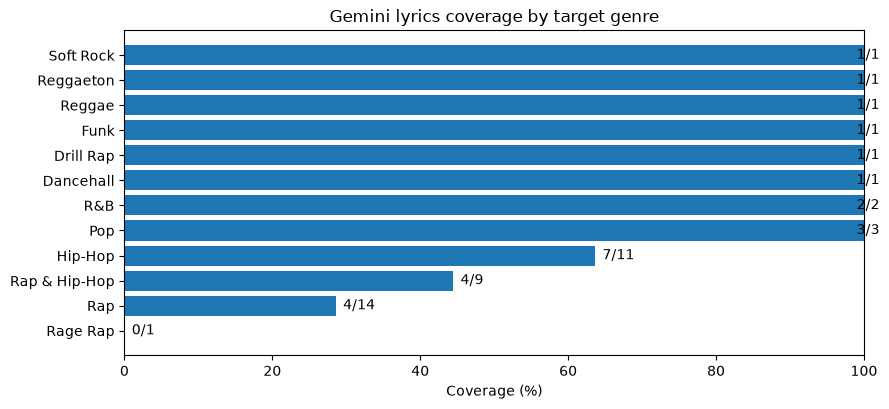

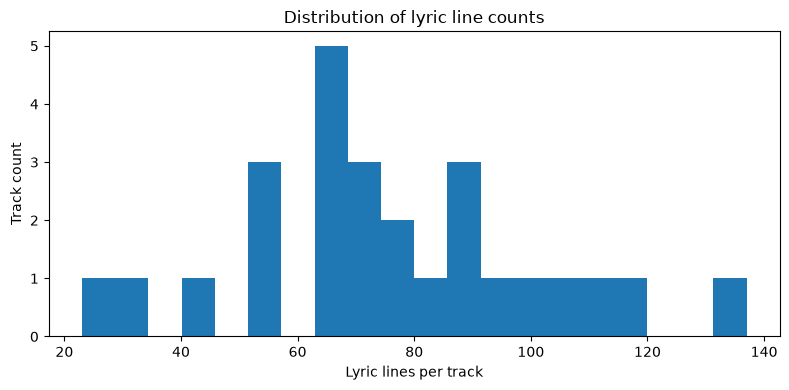

In [9]:
if plt is None:
    display(Markdown("Matplotlib is not installed, so charts are skipped."))
else:
    if not genre_coverage_df.empty:
        chart_df = genre_coverage_df.sort_values("coverage_pct", ascending=True)
        fig, ax = plt.subplots(figsize=(9, max(4, len(chart_df) * 0.35)))
        ax.barh(chart_df["genre"], chart_df["coverage_pct"] * 100)
        ax.set_title("Gemini lyrics coverage by target genre")
        ax.set_xlabel("Coverage (%)")
        ax.set_xlim(0, 100)
        for index, row in chart_df.reset_index(drop=True).iterrows():
            ax.text(
                min(row["coverage_pct"] * 100 + 1, 99),
                index,
                f"{row['tracks_with_lyrics']}/{row['target_genre_track_count']}",
                va="center",
            )
        plt.tight_layout()
        plt.show()

    if lyrics_row_count and lyrics_joined_df["lyric_line_count"].notna().any():
        fig, ax = plt.subplots(figsize=(8, 4))
        lyrics_joined_df["lyric_line_count"].dropna().plot(kind="hist", bins=20, ax=ax)
        ax.set_title("Distribution of lyric line counts")
        ax.set_xlabel("Lyric lines per track")
        ax.set_ylabel("Track count")
        plt.tight_layout()
        plt.show()

## Takeaways

In [10]:
takeaways = []
if lyrics_row_count == 0:
    takeaways.append("No Gemini lyrics rows have been imported yet. Run a successful Gemini batch import, then rerun this notebook.")
else:
    takeaways.append(f"The table currently contains {lyrics_row_count:,} lyrics rows covering {covered_eligible_count:,} of {eligible_count:,} target-genre Rekordbox tracks ({coverage_pct:.1%}).")
    if invalid_json_count:
        takeaways.append(f"{invalid_json_count:,} row(s) are not valid JSON and should be re-requested or inspected before downstream use.")
    else:
        takeaways.append("All imported rows parse as valid JSON.")
    if orphan_count:
        takeaways.append(f"{orphan_count:,} row(s) do not join back to `rekordbox_tracks`, which suggests stale or mismatched track IDs.")
    if not genre_coverage_df.empty:
        lowest = genre_coverage_df.iloc[0]
        takeaways.append(f"Lowest genre coverage is {lowest['genre']} at {lowest['coverage_pct']:.1%} ({lowest['tracks_with_lyrics']}/{lowest['target_genre_track_count']}).")

display(Markdown("\n".join(f"- {takeaway}" for takeaway in takeaways)))

- The table currently contains 26 lyrics rows covering 26 of 46 target-genre Rekordbox tracks (56.5%).
- All imported rows parse as valid JSON.
- Lowest genre coverage is Rage Rap at 0.0% (0/1).